In [1]:
import networkx as nx
import itertools
import matplotlib.pyplot as plt

In [3]:
def hamming_distance(a: int, b: int) -> int:
    """Distancia de Hamming entre dos enteros (popcount del XOR)."""
    return (a ^ b).bit_count()

def build_hamming_graph(n: int, d: int) -> nx.Graph:
    """
    Construye el grafo de Hamming H(n, d):
    - Vértices: números enteros de 0 a 2^n - 1 (representan palabras binarias)
    - Arista entre u y v si hamming_distance(u, v) >= d
    """
    num_vertices = 1 << n
    G = nx.Graph()
    G.add_nodes_from(range(num_vertices))
    for u in range(num_vertices):
        for v in range(u + 1, num_vertices):
            if hamming_distance(u, v) >= d:
                G.add_edge(u, v)
    return G


In [4]:
def bron_kerbosch_max_cliques(G: nx.Graph):
    """
    Implementación del algoritmo de Bron–Kerbosch (versión con pivote)
    que encuentra todos los cliques maximales en un grafo no dirigido.
    Adaptado del artículo original "Algorithm 457: Finding All Cliques of an Undirected Graph".
    Retorna una lista de cliques (cada clique es un conjunto de vértices).
    """
    # Convertir los vértices a enteros 0..N-1 (ya lo son)
    vertices = list(G.nodes())
    # Precalcular vecinos como lista de conjuntos para acceso rápido
    neighbors = {v: set(G.neighbors(v)) for v in vertices}
    N = len(vertices)
    # Orden inicial: todos los vértices en "candidates", "not" vacío
    all_vertices = vertices[:]  # lista de todos los vértices en orden
    compsub = []  # R, clique en construcción
    cliques = []  # almacenará los cliques maximales encontrados

    def extend(old, ne, ce):
        """
        old: lista de vértices (primero 'not' (0..ne-1), luego 'candidates' (ne..ce-1))
        ne: número de vértices en not (0 <= ne <= ce)
        ce: número total de elementos en old (len(old))
        """
        nonlocal cliques
        # Paso 1: elegir punto fijo (fixp) con mínimo número de disconexiones
        minnod = ce
        fixp = None
        s = -1
        nod = 0  # indicador si el punto fijo se tomó de candidates (1) o not (0)
        i = 0
        while i < ce and minnod != 0:
            p = old[i]
            count = 0
            # Contar disconexiones con el resto de candidatos (desde ne hasta ce-1)
            j = ne
            pos = -1
            while j < ce and count <= minnod:
                if p not in neighbors[old[j]]:  # disconexión
                    count += 1
                    pos = j
                j += 1
            if count < minnod:
                fixp = p
                minnod = count
                if i < ne:
                    s = pos
                else:
                    s = i
                    nod = 1
            i += 1

        # Bucle principal de backtracking
        # nod iterará desde minnod + nod hasta 1
        for _ in range(minnod + nod, 0, -1):
            # Intercambiar el candidato seleccionado (old[s]) con old[ne]
            p = old[s]
            old[s] = old[ne]
            sel = old[ne]
            old[ne] = p

            # Construir nuevo conjunto 'not' (new) y 'candidates' (newcand)
            new = [0] * ce  # preasignamos tamaño máximo
            newne = 0
            # Copiar vértices de 'not' que son vecinos de sel
            for i in range(ne):
                if sel in neighbors[old[i]]:
                    new[newne] = old[i]
                    newne += 1
            newce = newne
            # Copiar vértices de 'candidates' (desde ne+1 hasta ce-1) que son vecinos de sel
            # Nota: el índice ne ya contiene sel, que fue movido; lo saltamos
            for i in range(ne + 1, ce):
                if sel in neighbors[old[i]]:
                    new[newce] = old[i]
                    newce += 1

            compsub.append(sel)

            if newce == 0:
                # Se encontró un clique maximal
                cliques.append(compsub.copy())
            else:
                if newne < newce:
                    # Llamada recursiva con el nuevo conjunto
                    # new[:newce] contiene (not + candidates)
                    extend(new, newne, newce)

            compsub.pop()
            # Mover sel al conjunto 'not' para futuras iteraciones
            ne += 1

            # Si aún quedan candidatos por procesar (nod > 1), seleccionar el siguiente
            # candidato desconectado del punto fijo
            if nod > 1:
                # Buscar siguiente candidato (pos > s) que esté desconectado de fixp
                s = ne
                while s < ce and fixp in neighbors[old[s]]:
                    s += 1
                if s >= ce:
                    break
                # El siguiente candidato ya está en old[s], listo para el siguiente ciclo
            else:
                # Solo un candidato, terminar
                break

    # Iniciar llamada con todos los vértices en candidates, not vacío
    extend(all_vertices, 0, N)
    return cliques


In [58]:
G= build_hamming_graph(3,2)
cliques = bron_kerbosch_max_cliques(G)
cliques

[[0, 3, 5, 6]]

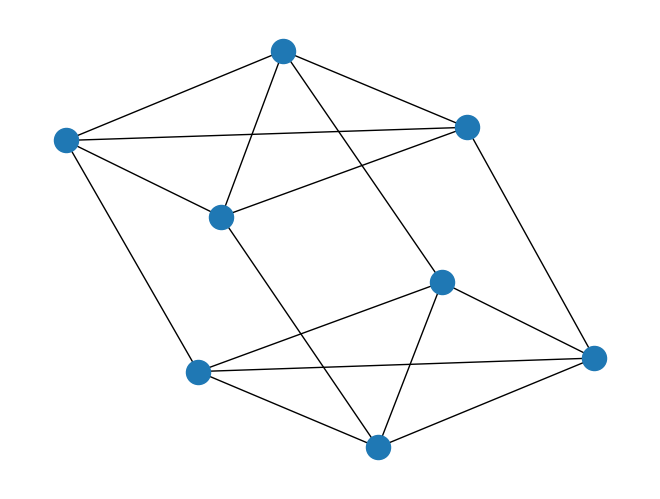

In [59]:
nx.draw(G)

In [60]:
G= build_hamming_graph(4,2)
cliques = bron_kerbosch_max_cliques(G)
cliques

[[0, 3, 5, 6, 10, 12, 15]]

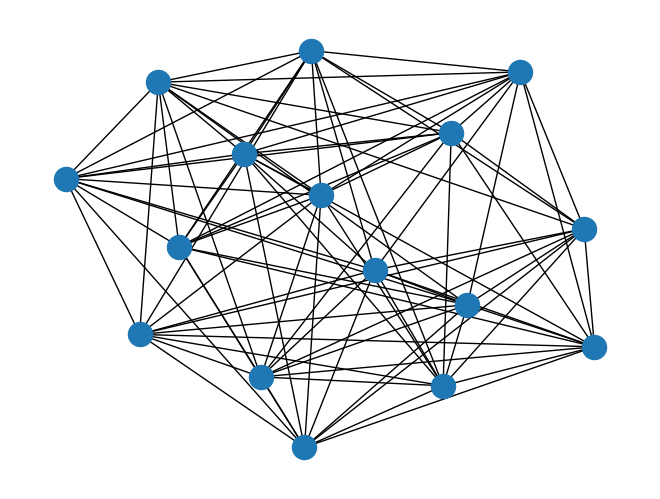

In [61]:
nx.draw(G)

In [11]:
def hamming_distance(x: int, y: int) -> int:
    return (x ^ y).bit_count()

def build_adjacency_bitsets(n: int, d: int, even_only: bool = False):
    """Grafo de adyacencia: arista si distancia >= d.
    Si even_only=True, solo vértices de peso par."""
    total = 1 << n
    vertices = [v for v in range(total) if (not even_only) or (v.bit_count() % 2 == 0)]
    N = len(vertices)
    idx = {v: i for i, v in enumerate(vertices)}
    adj = [0] * N
    for a in range(N):
        for b in range(a + 1, N):
            if hamming_distance(vertices[a], vertices[b]) >= d:
                adj[a] |= (1 << b)
                adj[b] |= (1 << a)
    return adj, N, vertices

def greedy_color(P_bits, adj):
    """Coloreo greedy del subgrafo inducido por P_bits.
    Devuelve (lista_vertices_ordenados, número_de_colores)."""
    verts = []
    bits = P_bits
    while bits:
        v = (bits & -bits).bit_length() - 1
        verts.append(v)
        bits &= bits - 1
    if not verts:
        return [], 0
    verts.sort(key=lambda v: (P_bits & adj[v]).bit_count(), reverse=True)
    color = {}
    max_c = -1
    for v in verts:
        used = set()
        neigh = adj[v] & P_bits
        nbits = neigh
        while nbits:
            u = (nbits & -nbits).bit_length() - 1
            if u in color:
                used.add(color[u])
            nbits &= nbits - 1
        c = 0
        while c in used:
            c += 1
        color[v] = c
        if c > max_c:
            max_c = c
    num_colors = max_c + 1
    sorted_verts = sorted(verts, key=lambda v: color[v], reverse=True)
    return sorted_verts, num_colors

def greedy_initial_clique(adj, N, vertices):
    """Cota inferior rápida: clique greedy. Devuelve (tamaño, bitset de la clique)."""
    order = list(range(N))
    order.sort(key=lambda v: -adj[v].bit_count())
    current = 0
    for v in order:
        if (current & adj[v]) == current:
            current |= (1 << v)
    return current.bit_count(), current

def max_clique_tomita(adj, N, vertices, use_translation=True):
    """Algoritmo de Tomita para el tamaño de la clique máxima.
    Devuelve (tamaño, bitset de la clique encontrada)."""
    # Clique inicial greedy
    max_size, best_clique_bits = greedy_initial_clique(adj, N, vertices)

    if use_translation:
        # Fijamos el vértice 0 (índice 0) en la clique
        R0 = 1 << 0
        P0 = (1 << N) - 1
        P0 &= adj[0]          # solo vecinos de 0
        X0 = 0
    else:
        R0 = 0
        P0 = (1 << N) - 1
        X0 = 0

    # Variable para almacenar la mejor clique encontrada (como bitset)
    # Inicialmente la mejor es la greedy
    best_clique = best_clique_bits

    def expand(R_bits, P_bits, X_bits):
        nonlocal max_size, best_clique
        cur_sz = R_bits.bit_count()
        # Poda simple
        if cur_sz + P_bits.bit_count() <= max_size:
            return
        if P_bits == 0 and X_bits == 0:
            if cur_sz > max_size:
                max_size = cur_sz
                best_clique = R_bits
            return
        # Poda por coloración
        sorted_cand, colors = greedy_color(P_bits, adj)
        if cur_sz + colors <= max_size:
            return
        # Pivote: vértice en P∪X con mayor vecindario en P
        union = P_bits | X_bits
        best_u = -1
        best_deg = -1
        temp = union
        while temp:
            u_bit = temp & -temp
            u = u_bit.bit_length() - 1
            deg = (P_bits & adj[u]).bit_count()
            if deg > best_deg:
                best_deg = deg
                best_u = u
            temp ^= u_bit
        # Candidatos = P \ N(best_u)
        candidates = P_bits & ~adj[best_u]
        for v in sorted_cand:
            v_bit = 1 << v
            if not (candidates & v_bit):
                continue
            expand(R_bits | v_bit,
                   P_bits & adj[v],
                   X_bits & adj[v])
            P_bits &= ~v_bit
            X_bits |= v_bit
            if cur_sz + P_bits.bit_count() <= max_size:
                break

    expand(R0, P0, X0)
    return max_size, best_clique

def A(n, d, verbose=True):
    """Calcula A(n,d) y devuelve (valor, código) donde código es una lista de enteros (palabras)."""
    even_only = (d % 2 == 0)   # reducción por paridad
    if verbose:
        print(f"Construyendo grafo de adyacencia (distancia ≥ {d}) para n={n}...")
    adj, N, vertices = build_adjacency_bitsets(n, d, even_only)
    if verbose:
        print(f"Vértices: {N} (reducción por paridad: {even_only})")
    start = time.time()
    size, clique_bits = max_clique_tomita(adj, N, vertices, use_translation=True)
    elapsed = time.time() - start
    
    # Convertir el bitset de la clique a una lista de palabras originales
    code = []
    bits = clique_bits
    while bits:
        v = (bits & -bits).bit_length() - 1
        code.append(vertices[v])
        bits &= bits - 1
    
    # Si usamos reducción por paridad, el código obtenido es de peso par. No es necesario volver a trasladar.
    if verbose:
        print(f"A({n},{d}) = {size}  (tiempo: {elapsed:.2f} segundos)")
        print("Código encontrado (palabras en decimal):")
        print(code)
        # Opcional: mostrar también en binario
        # print([format(w, f'0{n}b') for w in code])
    return size, code

if __name__ == "__main__":
    import time
    # Ejemplo
    A(8,4)

Construyendo grafo de adyacencia (distancia ≥ 4) para n=8...
Vértices: 128 (reducción por paridad: True)
A(8,4) = 16  (tiempo: 3.87 segundos)
Código encontrado (palabras en decimal):
[0, 15, 51, 60, 85, 90, 102, 105, 150, 153, 165, 170, 195, 204, 240, 255]
